In [262]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!echo  KGAT_d2db7bb735be829943a6187c23832176> ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

In [263]:
!kaggle datasets list -s accident

ref                                                           title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------  -----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
sobhanmoosavi/us-accidents                                    US Accidents (2016 - 2023)                        684855912  2023-05-28 00:54:47.207000         185837       2669                1  
nextmillionaire/car-accident-dataset                          Car Accident Dataset                                7399700  2024-01-10 23:04:21.073000           7401         82       0.88235295  
oktayrdeki/traffic-accidents                                  Traffic Accidents                                   4862299  2025-01-20 10:33:44.323000          15205        155                1  
himelsarder/road-accident

In [264]:
!kaggle datasets download -d sobhanmoosavi/us-accidents


Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
us-accidents.zip: Skipping, found more recently modified local copy (use --force to force download)


In [265]:
!unzip us-accidents.zip


Archive:  us-accidents.zip
replace US_Accidents_March23.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


# Car Accident Severity Prediction Using Machine Learning

## Project Overview

This project aims to predict accident severity using weather, location, traffic, and environmental conditions from the US Accidents dataset.

In [266]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import joblib

# Dataset Loading

The US Accidents dataset is loaded for preprocessing, analysis, and machine learning model development.

In [267]:
df = pd.read_csv(
    "US_Accidents_March23.csv",
    nrows=300000
)

print(df.shape)

(300000, 46)


# Dataset Overview

This section explores the structure, dimensions, and data types of the dataset.

In [268]:
df.head()

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     300000 non-null  object 
 1   Source                 300000 non-null  object 
 2   Severity               300000 non-null  int64  
 3   Start_Time             300000 non-null  object 
 4   End_Time               300000 non-null  object 
 5   Start_Lat              300000 non-null  float64
 6   Start_Lng              300000 non-null  float64
 7   End_Lat                0 non-null       float64
 8   End_Lng                0 non-null       float64
 9   Distance(mi)           300000 non-null  float64
 10  Description            300000 non-null  object 
 11  Street                 300000 non-null  object 
 12  City                   299984 non-null  object 
 13  County                 300000 non-null  object 
 14  State                  300000 non-nu

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,300000.000000,300000.000000,300000.000000,0.0,0.0,300000.000000,295644.000000,35615.000000,295193.000000,296487.000000,293337.000000,242246.000000,29036.000000
mean,2.371927,35.814760,-97.632531,NaN,NaN,0.049009,65.180581,30.510021,65.150159,30.018196,9.238826,8.515888,0.065433
std,0.486002,4.686140,18.412488,NaN,NaN,0.679245,16.977736,16.856171,21.207637,0.255681,2.109278,5.756141,0.538391
min,1.000000,25.433098,-123.813927,NaN,NaN,0.000000,-77.800000,-29.300000,4.000000,0.120000,0.000000,0.000000,0.000000
25%,2.000000,32.924090,-118.102577,NaN,NaN,0.000000,55.400000,22.200000,50.000000,29.910000,10.000000,5.000000,0.000000
50%,2.000000,34.257259,-95.520012,NaN,NaN,0.000000,66.900000,31.400000,67.000000,30.010000,10.000000,8.100000,0.010000
75%,3.000000,40.064110,-81.494834,NaN,NaN,0.010000,77.000000,38.200000,82.000000,30.120000,10.000000,10.400000,0.030000
max,4.000000,44.895218,-70.571518,NaN,NaN,80.890000,161.600000,111.000000,100.000000,33.040000,105.000000,822.800000,10.140000


# Missing Value Analysis

Identify missing values present in the dataset before preprocessing.

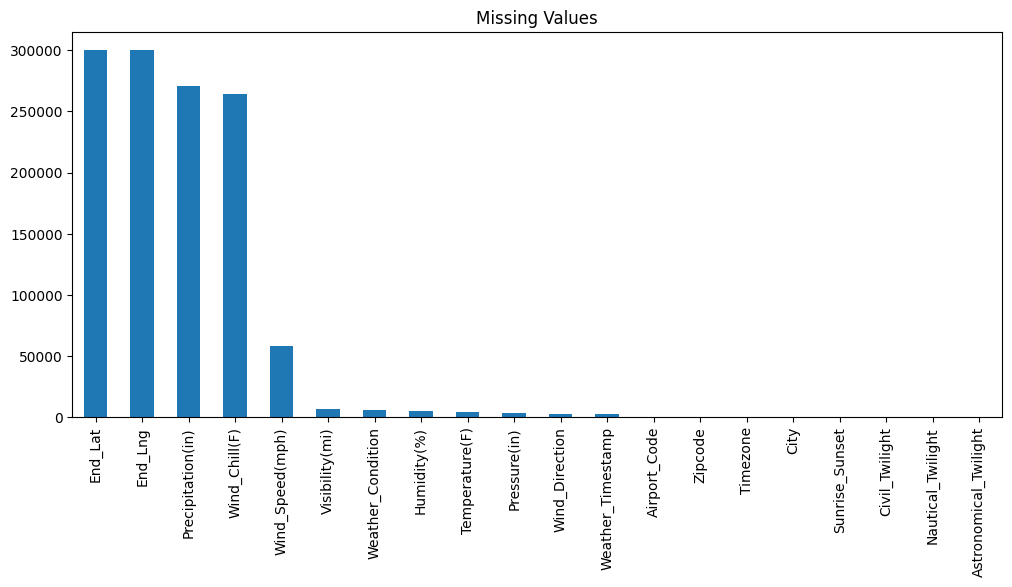

In [269]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Missing Values")
plt.show()

# Data Cleaning

Remove irrelevant and redundant features that do not contribute significantly to accident severity prediction.

In [270]:
drop_cols = [
    'End_Time',
    'End_Lat',
    'End_Lng',
    'Zipcode',
    'Airport_Code',
    'Weather_Timestamp',
    'Timezone',
    'Source',
    'Country'
]

df.drop(
    columns=drop_cols,
    inplace=True,
    errors='ignore'
)

In [271]:
df.drop(
    columns=[
        'Precipitation(in)',
        'Wind_Chill(F)'
    ],
    inplace=True
)

In [272]:
num_cols = [
    'Temperature(F)',
    'Humidity(%)',
    'Pressure(in)',
    'Visibility(mi)',
    'Wind_Speed(mph)'
]

for col in num_cols:
    df[col].fillna(
        df[col].median(),
        inplace=True
    )

/tmp/ipykernel_10613/2733001388.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(


In [273]:
cat_cols = [
    'Weather_Condition',
    'Wind_Direction',
    'City',
    'Sunrise_Sunset',
    'Civil_Twilight',
    'Nautical_Twilight',
    'Astronomical_Twilight'
]

for col in cat_cols:
    df[col].fillna(
        df[col].mode()[0],
        inplace=True
    )

/tmp/ipykernel_10613/2436280071.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(


# Exploratory Data Analysis (EDA)

Analyze accident patterns, severity distribution, and weather conditions.
## Accident Severity Distribution

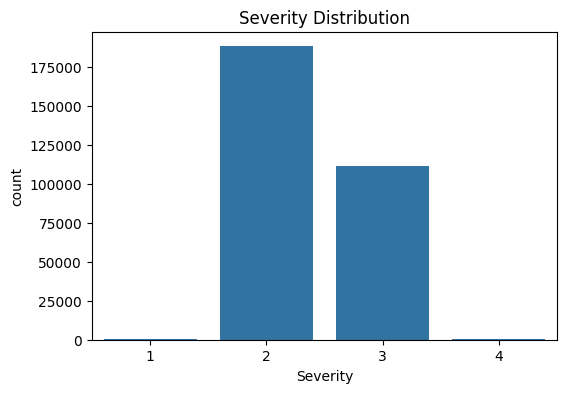

In [274]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Severity',
    data=df
)

plt.title("Severity Distribution")
plt.show()

## Weather Condition Analysis

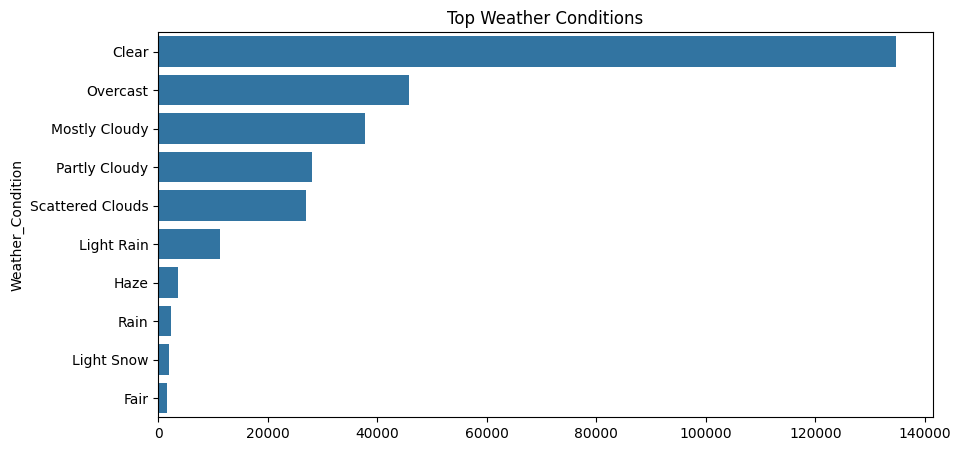

In [275]:
top_weather = (
    df['Weather_Condition']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_weather.values,
    y=top_weather.index
)

plt.title("Top Weather Conditions")
plt.show()

# Feature Engineering

Extract meaningful time-based features from the Start_Time column.

In [276]:
df['Start_Time'] = pd.to_datetime(
    df['Start_Time']
)

df['Hour'] = (
    df['Start_Time']
    .dt.hour
)

df['Month'] = (
    df['Start_Time']
    .dt.month
)

df['DayOfWeek'] = (
    df['Start_Time']
    .dt.dayofweek
)

df['Year'] = (
    df['Start_Time']
    .dt.year
)

df.drop(
    'Start_Time',
    axis=1,
    inplace=True
)

## Accidents by Hour

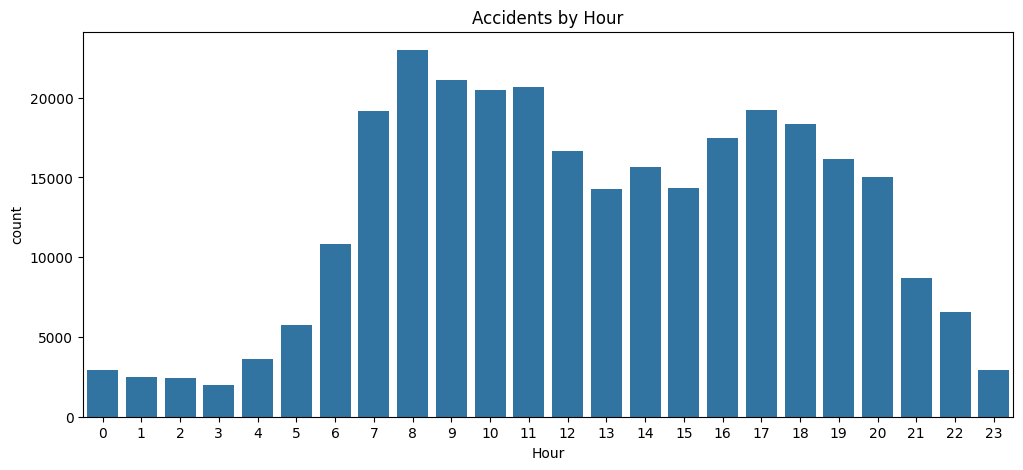

In [277]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='Hour',
    data=df
)

plt.title("Accidents by Hour")

plt.show()

# Outlier Detection

Visualize outliers in numerical features using boxplots.

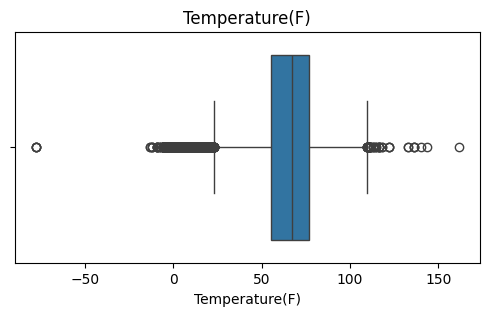

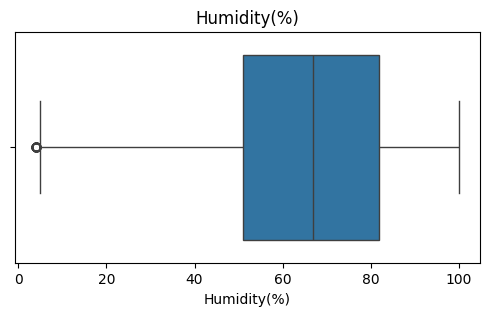

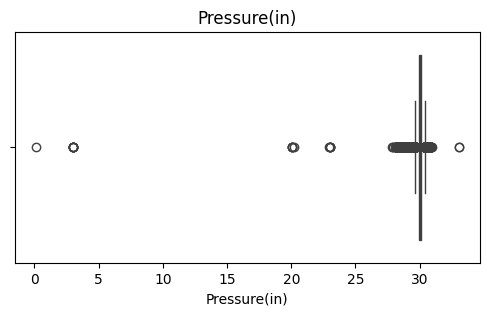

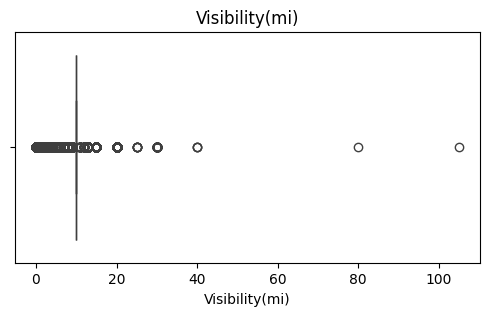

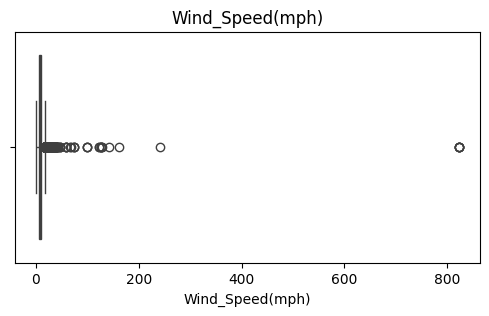

In [278]:
num_cols = [
    'Temperature(F)',
    'Humidity(%)',
    'Pressure(in)',
    'Visibility(mi)',
    'Wind_Speed(mph)'
]

for col in num_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

# Outlier Treatment Using IQR

Remove extreme values using the Interquartile Range (IQR) method.

In [279]:
def remove_outliers(df,col):

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR

    upper = Q3 + 1.5*IQR

    return df[
        (df[col] >= lower)
        &
        (df[col] <= upper)
    ]

for col in num_cols:

    df = remove_outliers(
        df,
        col
    )

# Correlation Heatmap

Analyze relationships between numerical variables.

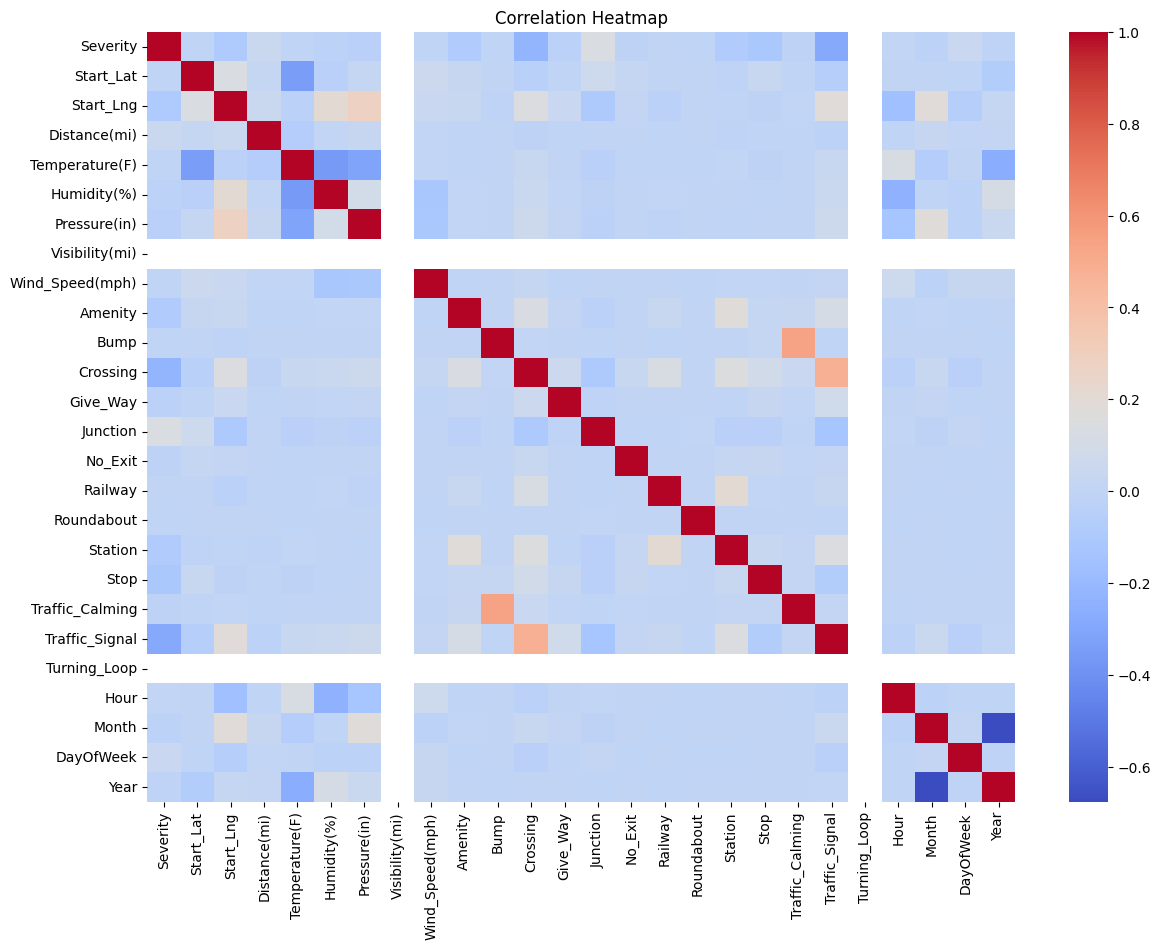

In [280]:
plt.figure(figsize=(14,10))

corr = df.corr(
    numeric_only=True
)

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

# Severity Transformation

Convert the multiclass severity variable into a binary classification problem.

In [281]:
df['Severity'] = (
    df['Severity']
    .replace({
        1:0,
        2:0,
        3:1,
        4:1
    })
)

# Categorical Feature Encoding

Convert categorical features into numerical representations using One-Hot Encoding and Label Encoding.

In [282]:
one_hot_cols = [
    'Weather_Condition',
    'Wind_Direction',
    'Sunrise_Sunset'
]

df = pd.get_dummies(
    df,
    columns=one_hot_cols,
    drop_first=True
)

In [283]:
high_card_cols = [
    'City',
    'County',
    'State'
]

le = LabelEncoder()

for col in high_card_cols:

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

# Train-Test Split

Split the dataset into training and testing subsets.

In [284]:
X = df.drop(
    ['Severity', 'ID'], # Drop 'ID' column as it's not a predictive feature
    axis=1
)

y = df['Severity']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [285]:
df.drop(
    columns=[
        'ID',
        'Description',
        'Street'
    ],
    inplace=True,
    errors='ignore'
)

In [286]:
df = pd.get_dummies(
    df,
    columns=[
        'Civil_Twilight',
        'Nautical_Twilight',
        'Astronomical_Twilight'
    ],
    drop_first=True
)

In [287]:
print(df.select_dtypes(include='object').columns)

Index([], dtype='object')


In [288]:
X = df.drop('Severity', axis=1)

y = df['Severity']

In [289]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Decision Tree Classifier

Train a baseline Decision Tree model for accident severity prediction.

In [290]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [291]:
from sklearn.metrics import accuracy_score, classification_report

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.7727551601735396
              precision    recall  f1-score   support

           0       0.80      0.84      0.82     28545
           1       0.71      0.66      0.68     17093

    accuracy                           0.77     45638
   macro avg       0.76      0.75      0.75     45638
weighted avg       0.77      0.77      0.77     45638



## Decision Tree Visualization

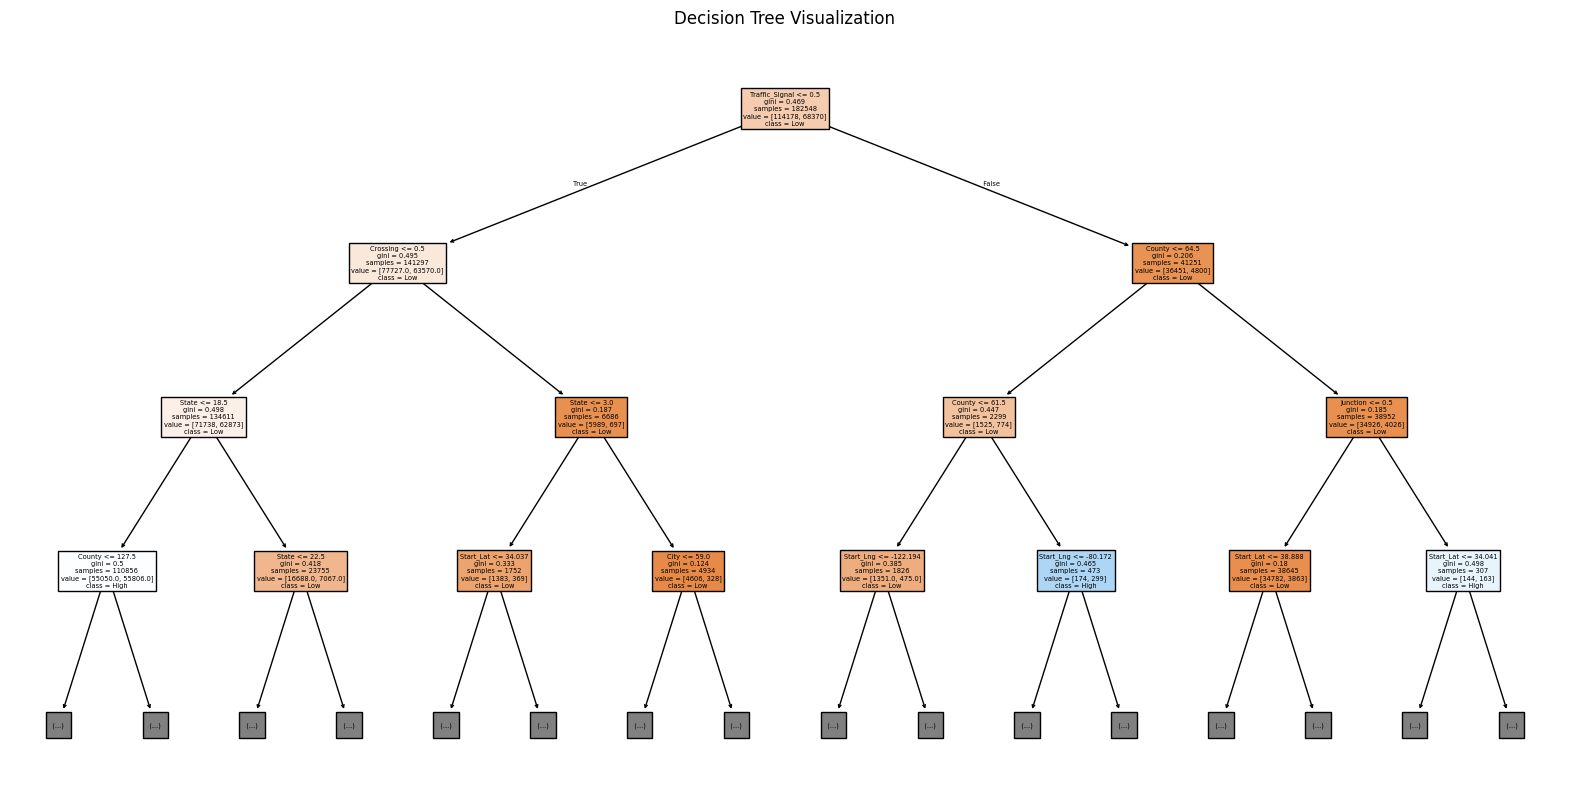

In [292]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    max_depth=3,
    filled=True,
    feature_names=X.columns,
    class_names=['Low','High']
)

plt.title("Decision Tree Visualization")
plt.show()

# Random Forest Classifier

Train an ensemble learning model using multiple decision trees.

In [293]:


rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [294]:
y_pred = rf.predict(X_test)

In [295]:
print(len(y_test))
print(len(y_pred))

45638
45638


In [296]:


print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8484157938559972
              precision    recall  f1-score   support

           0       0.87      0.89      0.88     28545
           1       0.81      0.77      0.79     17093

    accuracy                           0.85     45638
   macro avg       0.84      0.83      0.84     45638
weighted avg       0.85      0.85      0.85     45638



# XGBoost Classifier

Train a boosting-based ensemble model and compare its performance.

In [297]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

pred = xgb.predict(
    X_test
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

print(
    classification_report(
        y_test,
        pred
    )
)

Accuracy: 0.8215741268241378
              precision    recall  f1-score   support

           0       0.86      0.86      0.86     28545
           1       0.76      0.76      0.76     17093

    accuracy                           0.82     45638
   macro avg       0.81      0.81      0.81     45638
weighted avg       0.82      0.82      0.82     45638



# Confusion Matrix

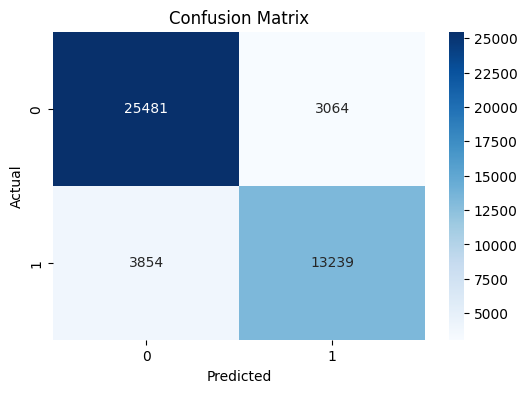

In [298]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ROC Curve and AUC Score

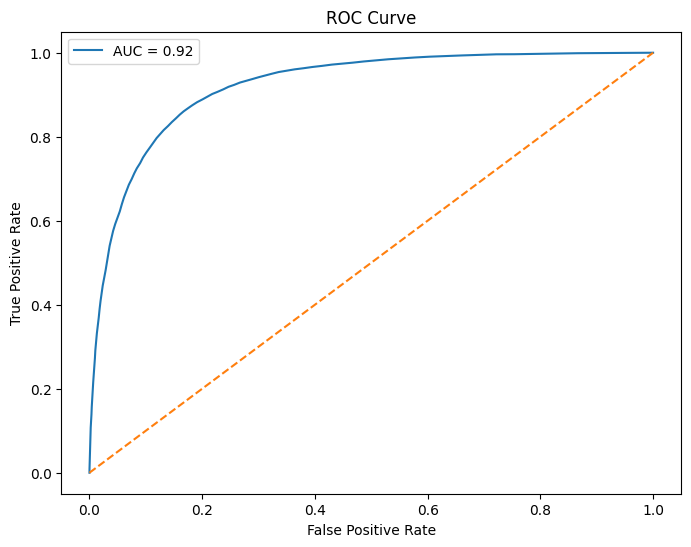

In [299]:
y_prob = rf.predict_proba(
    X_test
)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.show()

# Feature Importance Analysis

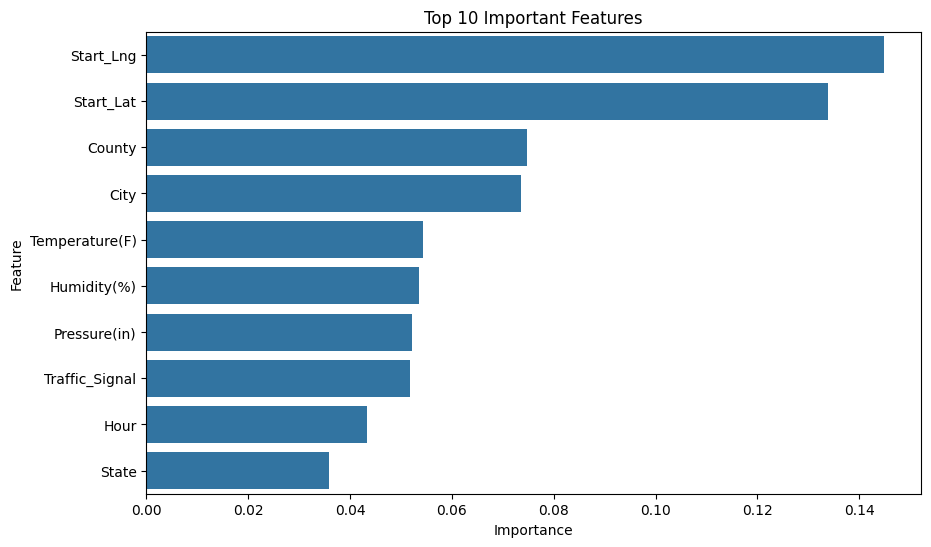

In [300]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance':
    rf.feature_importances_

})

importance = (
    importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

plt.figure(
    figsize=(10,6)
)

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

# Model Comparison

In [302]:
rf_acc = accuracy_score(y_test, y_pred)
xgb_acc = accuracy_score(y_test, pred)

results = pd.DataFrame({

    'Model': [
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [
        dt_acc,
        rf_acc,
        xgb_acc
    ]
})

In [303]:
print(
    results.sort_values(
        by='Accuracy',
        ascending=False
    )
)

           Model  Accuracy
1  Random Forest  0.848416
2        XGBoost  0.821574
0  Decision Tree  0.772755


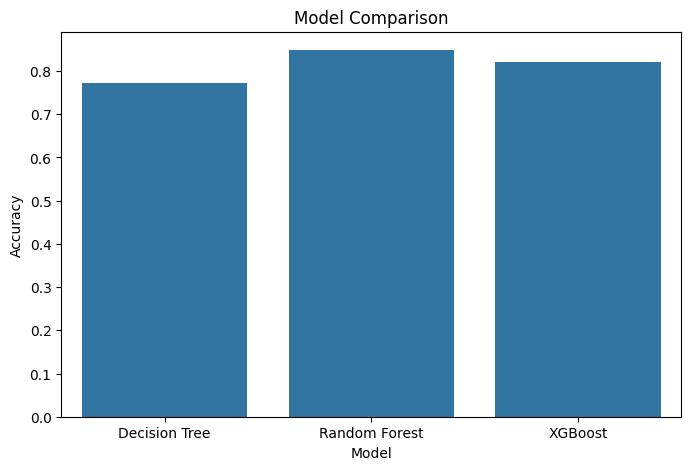

In [304]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title("Model Comparison")

plt.show()

# Best Model Selection

After evaluating Decision Tree, Random Forest, and XGBoost models, the best-performing model is identified based on accuracy. This helps in selecting the final model for accident severity prediction and deployment.

In [305]:
best_model = results.loc[
    results['Accuracy'].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model       Random Forest
Accuracy         0.848416
Name: 1, dtype: object


# Model Saving

Save the best-performing model for future use and deployment.

In [306]:
import joblib

joblib.dump(
    rf,
    'car_accident_model.pkl'
)

print("Model Saved Successfully")

Model Saved Successfully


# Conclusion

This project successfully developed an end-to-end machine learning pipeline for accident severity prediction using the US Accidents dataset.

Key Highlights:
- Data Cleaning and Missing Value Treatment
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Outlier Detection and Treatment
- One-Hot Encoding
- Decision Tree, Random Forest, and XGBoost Models
- Confusion Matrix and ROC Curve Analysis
- Feature Importance Analysis
- Model Comparison and Selection

Among all models, Random Forest achieved the best performance and was selected as the final model.